# Benchmarking ODE Solvers
To determine which one is best to implement for our chaotic systems

## 1. Manual Solvers Comparison
Comparing Euler, Predictor-Corrector (Heun) and Runge-Kutta 4

Generating Ground Truth (High Precision RK4)...
Running Convergence Tests...


/var/folders/54/mtlhlgq50bl57539r6f7t1j00000gn/T/ipykernel_41991/1557694137.py:8: RuntimeWarning: overflow encountered in scalar multiply
  dydt = x * (rho - z) - y
/var/folders/54/mtlhlgq50bl57539r6f7t1j00000gn/T/ipykernel_41991/1557694137.py:9: RuntimeWarning: overflow encountered in scalar multiply
  dzdt = x * y - beta * z
/var/folders/54/mtlhlgq50bl57539r6f7t1j00000gn/T/ipykernel_41991/1557694137.py:8: RuntimeWarning: invalid value encountered in scalar subtract
  dydt = x * (rho - z) - y
/var/folders/54/mtlhlgq50bl57539r6f7t1j00000gn/T/ipykernel_41991/1557694137.py:17: RuntimeWarning: invalid value encountered in add
  y = y + func(y) * dt
/var/folders/54/mtlhlgq50bl57539r6f7t1j00000gn/T/ipykernel_41991/1557694137.py:25: RuntimeWarning: invalid value encountered in add
  y = y + (func(y) + func(prediction)) * dt / 2


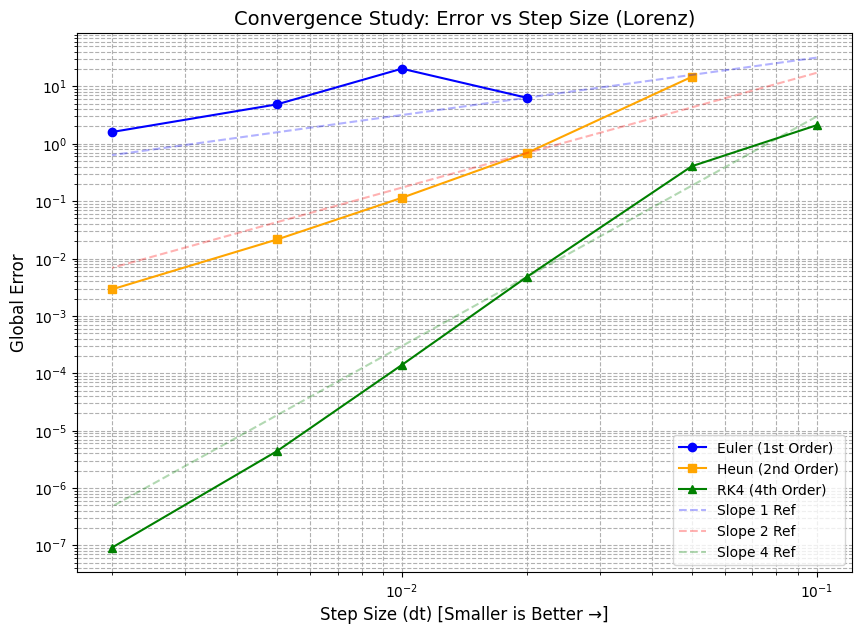

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define Lorenz System
def lorenz_deriv(state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return np.array([dxdt, dydt, dzdt])

# Manual Solvers (Final State Only)
def solve_euler_final(func, y0, dt, t_end):
    steps = int(t_end / dt)
    y = y0
    for _ in range(steps):
        y = y + func(y) * dt
    return y

def solve_heun_final(func, y0, dt, t_end):
    steps = int(t_end / dt)
    y = y0
    for _ in range(steps):
        prediction = y + func(y) * dt
        y = y + (func(y) + func(prediction)) * dt / 2
    return y

def solve_rk4_final(func, y0, dt, t_end):
    steps = int(t_end / dt)
    y = y0
    for _ in range(steps):
        k1 = func(y)
        k2 = func(y + k1 * dt/2)
        k3 = func(y + k2 * dt/2)
        k4 = func(y + k3 * dt)
        y = y + (k1 + 2*k2 + 2*k3 + k4) * dt / 6
    return y

# Convergence Study 
initial_state = np.array([1.0, 1.0, 1.0])
T_benchmark = 2.0 
dt_ref = 0.0001
dt_values = [0.1, 0.05, 0.02, 0.01, 0.005, 0.002]

print("Generating Ground Truth (High Precision RK4)...")
truth = solve_rk4_final(lorenz_deriv, initial_state, dt_ref, T_benchmark)

errors = {'Euler': [], 'Heun': [], 'RK4': []}

print("Running Convergence Tests...")
for dt in dt_values:
    y_euler = solve_euler_final(lorenz_deriv, initial_state, dt, T_benchmark)
    y_heun  = solve_heun_final(lorenz_deriv, initial_state, dt, T_benchmark)
    y_rk4   = solve_rk4_final(lorenz_deriv, initial_state, dt, T_benchmark)
    
    errors['Euler'].append(np.linalg.norm(y_euler - truth))
    errors['Heun'].append(np.linalg.norm(y_heun - truth))
    errors['RK4'].append(np.linalg.norm(y_rk4 - truth))

# Plotting
plt.figure(figsize=(10, 7))
plt.loglog(dt_values, errors['Euler'], 'o-', label='Euler (1st Order)', color='blue')
plt.loglog(dt_values, errors['Heun'], 's-', label='Heun (2nd Order)', color='orange')
plt.loglog(dt_values, errors['RK4'], '^-', label='RK4 (4th Order)', color='green')

# Reference Slopes (Anchored to middle point)
mid = 2
plt.loglog(dt_values, [errors['Euler'][mid] * (d/dt_values[mid])**1 for d in dt_values], 'b--', alpha=0.3, label='Slope 1 Ref')
plt.loglog(dt_values, [errors['Heun'][mid] * (d/dt_values[mid])**2 for d in dt_values], 'r--', alpha=0.3, label='Slope 2 Ref')
plt.loglog(dt_values, [errors['RK4'][mid] * (d/dt_values[mid])**4 for d in dt_values], 'g--', alpha=0.3, label='Slope 4 Ref')

plt.xlabel('Step Size (dt) [Smaller is Better →]', fontsize=12)
plt.ylabel('Global Error', fontsize=12)
plt.title('Convergence Study: Error vs Step Size (Lorenz)', fontsize=14)
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

## 2. Manual vs. SciPy Runge-Kutta
Comparing manual RK4 with SciPy's default RK4(5)


--- Benchmarking Lorenz ---
Manual (dt=0.01): 2000 steps, 0.0274s
SciPy (Adaptive):   496 steps, 0.0198s


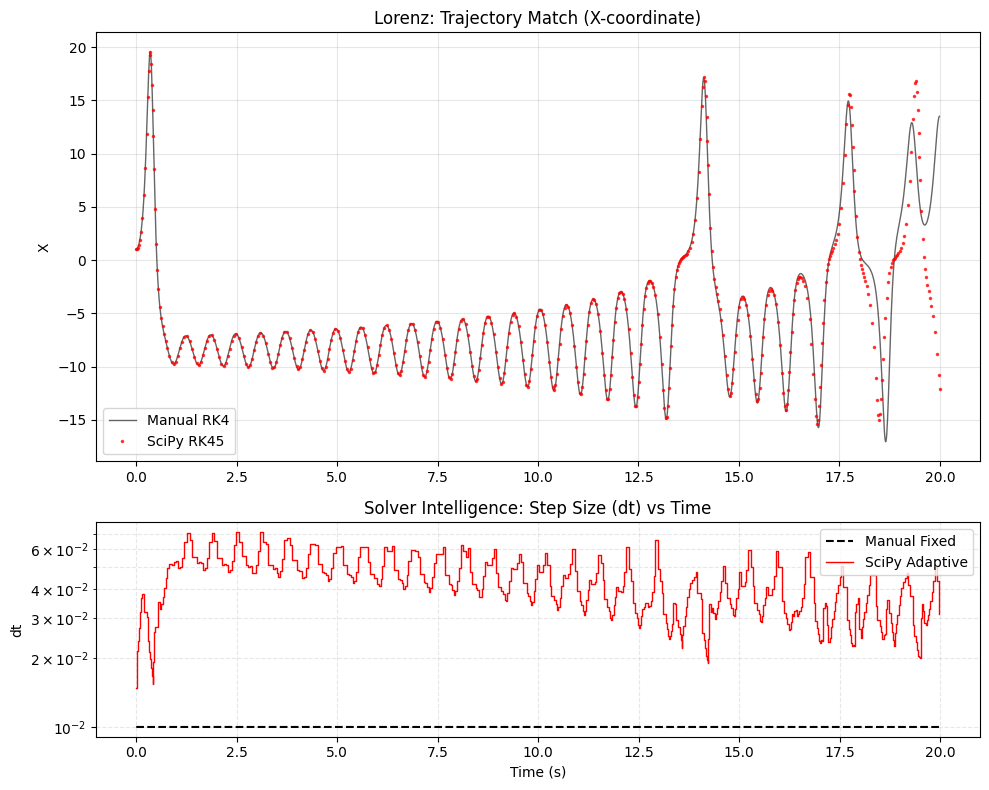

In [2]:
from scipy.integrate import solve_ivp
import time

# Define Solvers
def solve_rk4_trajectory(func, y0, t):
    """Manual RK4 that returns full history"""
    dt = t[1] - t[0]
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    for i in range(len(t) - 1):
        k1 = func(y[i])
        k2 = func(y[i] + k1 * dt/2)
        k3 = func(y[i] + k2 * dt/2)
        k4 = func(y[i] + k3 * dt)
        y[i+1] = y[i] + (k1 + 2*k2 + 2*k3 + k4) * dt / 6
    return y

def compare_solvers_performance(system_name, deriv_func, y0, T, manual_dt):
    print(f"\n--- Benchmarking {system_name} ---")
    
    # A. Manual RK4
    t_man = np.arange(0, T, manual_dt)
    start = time.perf_counter()
    sol_man = solve_rk4_trajectory(deriv_func, y0, t_man)
    time_man = time.perf_counter() - start
    
    # B. SciPy RK45 (Adaptive)
    # Wrapper: solve_ivp expects (t,y), our physics functions use (y)
    scipy_func = lambda t, y: deriv_func(y)
    start = time.perf_counter()
    sol_scipy = solve_ivp(scipy_func, [0, T], y0, method='RK45', rtol=1e-5, atol=1e-6)
    time_scipy = time.perf_counter() - start
    
    # Metrics
    steps_scipy = len(sol_scipy.t)
    dt_scipy = np.diff(sol_scipy.t)
    
    print(f"Manual (dt={manual_dt}): {len(t_man)} steps, {time_man:.4f}s")
    print(f"SciPy (Adaptive):   {steps_scipy} steps, {time_scipy:.4f}s")
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1])
    
    # Trajectory Overlay
    ax1.plot(t_man, sol_man[:, 0], 'k-', alpha=0.6, lw=1, label='Manual RK4')
    ax1.plot(sol_scipy.t, sol_scipy.y[0], 'r.', markersize=3, alpha=0.7, label='SciPy RK45')
    ax1.set_title(f"{system_name}: Trajectory Match (X-coordinate)")
    ax1.set_ylabel("X")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Step Size Analysis
    ax2.plot(t_man, [manual_dt]*len(t_man), 'k--', label='Manual Fixed')
    ax2.step(sol_scipy.t[:-1], dt_scipy, 'r-', where='post', lw=1, label='SciPy Adaptive')
    ax2.set_title("Solver Intelligence: Step Size (dt) vs Time")
    ax2.set_ylabel("dt")
    ax2.set_xlabel("Time (s)")
    ax2.set_yscale('log')
    ax2.legend()
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run the comparison on Lorenz
compare_solvers_performance("Lorenz", lorenz_deriv, [1.0, 1.0, 1.0], T=20.0, manual_dt=0.01)

### 2.1 Manual vs. SciPy Runge-Kutta: Phase Space Diagrams and Time Series

[Lorenz System] Divergence detected at t = 13.98s


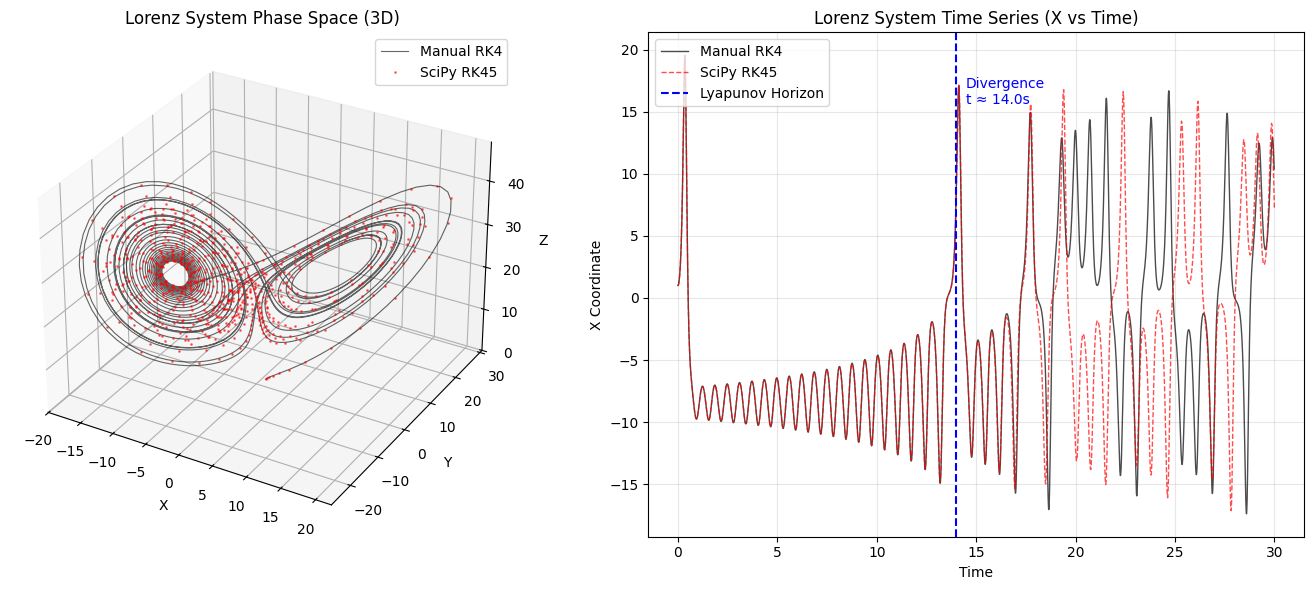

[Rössler System] No divergence detected within T=60.0s


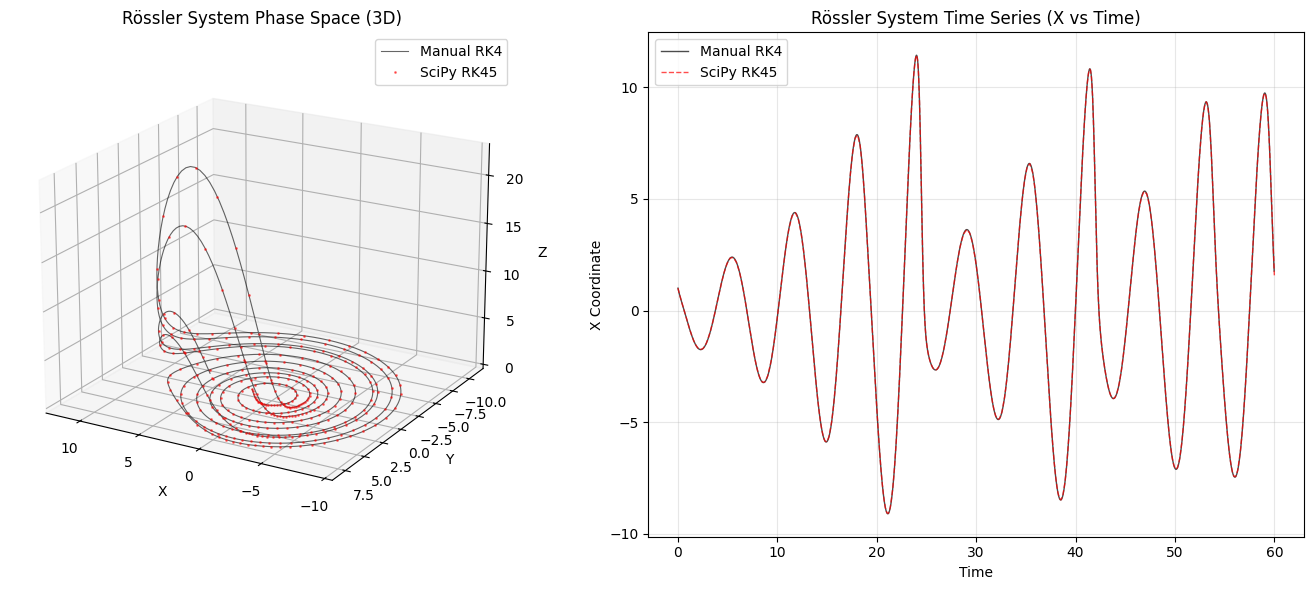

[Rössler System (Long Run)] Divergence detected at t = 100.70s


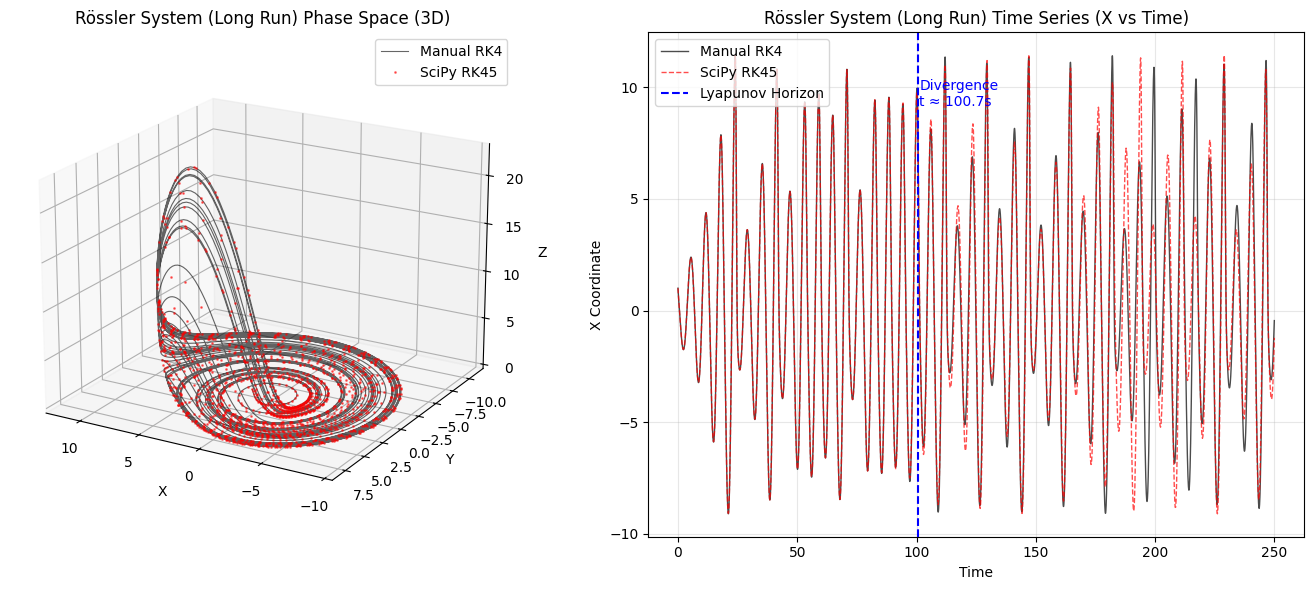

In [3]:
from scipy.interpolate import interp1d

def rossler_deriv(state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    dxdt = -y - z
    dydt = x + a * y
    dzdt = b + z * (x - c)
    return np.array([dxdt, dydt, dzdt])

# Visualization Function with Lyapunov Indicator
def plot_phase_and_time(system_name, deriv_func, y0, T, manual_dt, threshold=1.0, view_elev=30, view_azim=-60):
    # Run Manual Solver
    t_man = np.arange(0, T, manual_dt)
    sol_man = solve_rk4_trajectory(deriv_func, y0, t_man)
    
    # Run SciPy Solver
    scipy_func = lambda t, y: deriv_func(y)
    # dense_output=True allows us to evaluate the solution at any t later
    sol_scipy = solve_ivp(scipy_func, [0, T], y0, method='RK45', rtol=1e-5, atol=1e-6, dense_output=True)
    
    # Calculate Lyapunov Time (Divergence Point)
    # Interpolate SciPy solution onto the Manual time grid for comparison
    scipy_interpolated = sol_scipy.sol(t_man).T
    
    # Calculate Euclidean distance between the two trajectories at every step
    # dist = sqrt((x1-x2)^2 + (y1-y2)^2 + (z1-z2)^2)
    dist = np.linalg.norm(sol_man - scipy_interpolated, axis=1)
    
    # Find first index where distance > threshold
    divergence_indices = np.where(dist > threshold)[0]
    
    t_div = None
    if len(divergence_indices) > 0:
        t_div = t_man[divergence_indices[0]]
        print(f"[{system_name}] Divergence detected at t = {t_div:.2f}s")
    else:
        print(f"[{system_name}] No divergence detected within T={T}s")

    # Plotting
    fig = plt.figure(figsize=(14, 6))
    
    # Left Plot: 3D Phase Space
    ax3d = fig.add_subplot(1, 2, 1, projection='3d')
    ax3d.plot(sol_man[:,0], sol_man[:,1], sol_man[:,2], 'k-', lw=0.8, alpha=0.6, label='Manual RK4')
    ax3d.plot(sol_scipy.y[0], sol_scipy.y[1], sol_scipy.y[2], 'r.', markersize=2, alpha=0.5, label='SciPy RK45')
    
    ax3d.set_title(f"{system_name} Phase Space (3D)")
    ax3d.set_xlabel("X")
    ax3d.set_ylabel("Y")
    ax3d.set_zlabel("Z")
    ax3d.view_init(elev=view_elev, azim=view_azim)
    ax3d.legend()
    
    # Right Plot: Time Series
    axTS = fig.add_subplot(1, 2, 2)
    
    # Determine which variable to plot (X for Lorenz, Y for Rossler usually looks best)
    plot_idx = 1 if "Rossler" in system_name else 0
    var_label = "Y" if "Rossler" in system_name else "X"
    
    axTS.plot(t_man, sol_man[:, plot_idx], 'k-', lw=1, alpha=0.7, label='Manual RK4')
    axTS.plot(sol_scipy.t, sol_scipy.y[plot_idx], 'r--', lw=1, alpha=0.7, label='SciPy RK45')
    
    # Add Lyapunov Indicator if divergence exists
    if t_div is not None:
        axTS.axvline(x=t_div, color='blue', linestyle='--', linewidth=1.5, label='Lyapunov Horizon')
        axTS.text(t_div + 0.5, np.max(sol_man[:, plot_idx])*0.8, 
                  f"Divergence\nt ≈ {t_div:.1f}s", color='blue', fontsize=10)
    
    axTS.set_title(f"{system_name} Time Series ({var_label} vs Time)")
    axTS.set_xlabel("Time")
    axTS.set_ylabel(f"{var_label} Coordinate")
    axTS.grid(True, alpha=0.3)
    axTS.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Execute Plots
# Lorenz
# We use T=30 to ensure we capture the divergence
plot_phase_and_time("Lorenz System", lorenz_deriv, [1.0, 1.0, 1.0], T=30.0, manual_dt=0.01)

# Rössler
plot_phase_and_time("Rössler System", rossler_deriv, [1.0, 1.0, 1.0], T=60.0, manual_dt=0.02, view_elev=20, view_azim=120)

# Run Rössler for longer to catch the slower divergence
# T=250 should be enough to see the manual and scipy solvers disagree
plot_phase_and_time(
    "Rössler System (Long Run)", 
    rossler_deriv, 
    [1.0, 1.0, 1.0], 
    T=250.0,            # Increased from 60 to 250
    manual_dt=0.02, 
    view_elev=20, 
    view_azim=120
)